# Foresight: Exploratory Data Analysis & Modeling
This notebook walks through the data cleaning, exploratory analysis, and model training pipeline.

In [3]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, auc, precision_recall_curve, roc_curve, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.patches as patches

# Set clean styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style="whitegrid", palette="muted")
DPI = 150

# Load data
df_raw = pd.read_csv('../data/raw/ai4i2020.csv')
df_raw.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 1. Missing Values & Data Integrity

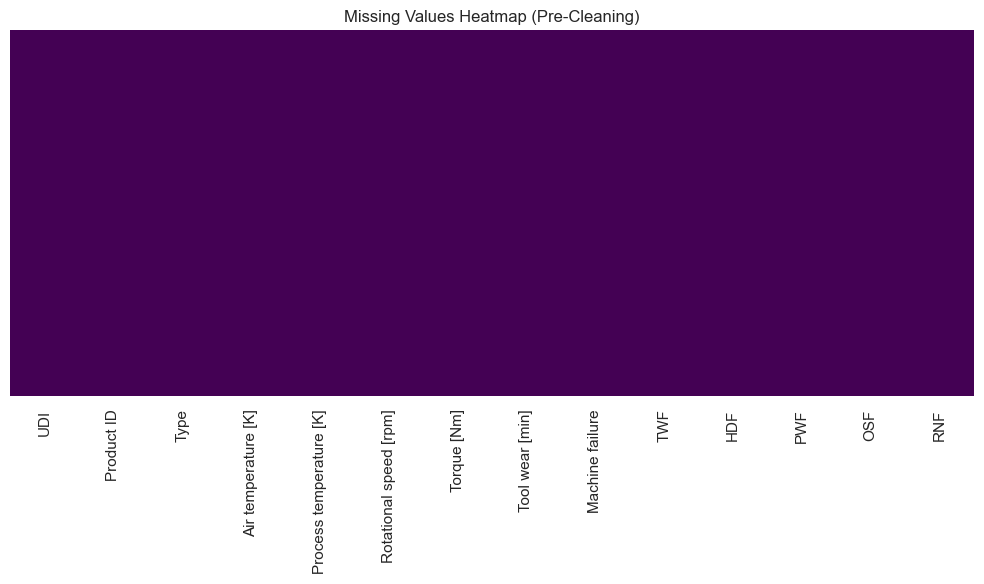

In [4]:
# 1. Missing values heatmap (pre-cleaning)
plt.figure(figsize=(10, 6))
sns.heatmap(df_raw.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap (Pre-Cleaning)")
plt.tight_layout()
plt.show()


## 2. Feature Engineering & Preprocessing
We drop identifiers and leakage targets, then engineer physics-based features.

In [5]:
df = df_raw.copy()
df.columns = [c.strip() for c in df.columns]

# Drop UDI and Product ID
df = df.drop(columns=["UDI", "Product ID"])
df = pd.get_dummies(df, columns=["Type"], drop_first=True)

# Feature Engineering
df["Temp_Diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
df["Power"] = df["Torque [Nm]"] * (df["Rotational speed [rpm]"] * 2 * np.pi / 60)
df["Tool_Wear_Rate"] = df["Tool wear [min]"] * df["Torque [Nm]"]

# Targets to drop to avoid leakage
leakage_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]
df = df.drop(columns=leakage_cols)

target = "Machine failure"
X = df.drop(columns=[target])
y = df[target]

df.head()


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_L,Type_M,Temp_Diff,Power,Tool_Wear_Rate
0,298.1,308.6,1551,42.8,0,0,False,True,10.5,6951.590560,0.0
1,298.2,308.7,1408,46.3,3,0,True,False,10.5,6826.722724,138.9
2,298.1,308.5,1498,49.4,5,0,True,False,10.4,7749.387543,247.0
3,298.2,308.6,1433,39.5,7,0,True,False,10.4,5927.504659,276.5
4,298.2,308.7,1408,40.0,9,0,True,False,10.5,5897.816608,360.0


## 3. Correlation Heatmap

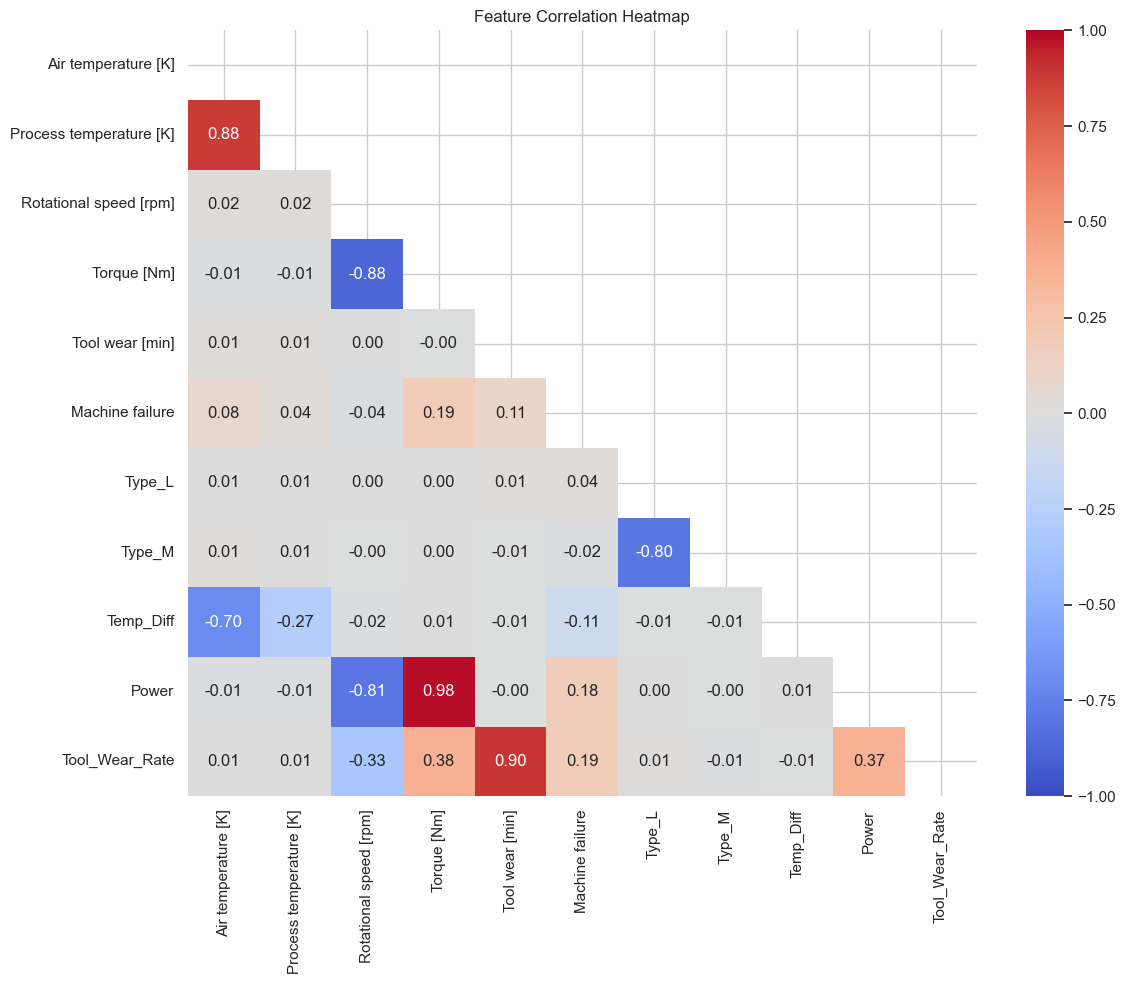

In [6]:
plt.figure(figsize=(12, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


## 4. Feature Distributions

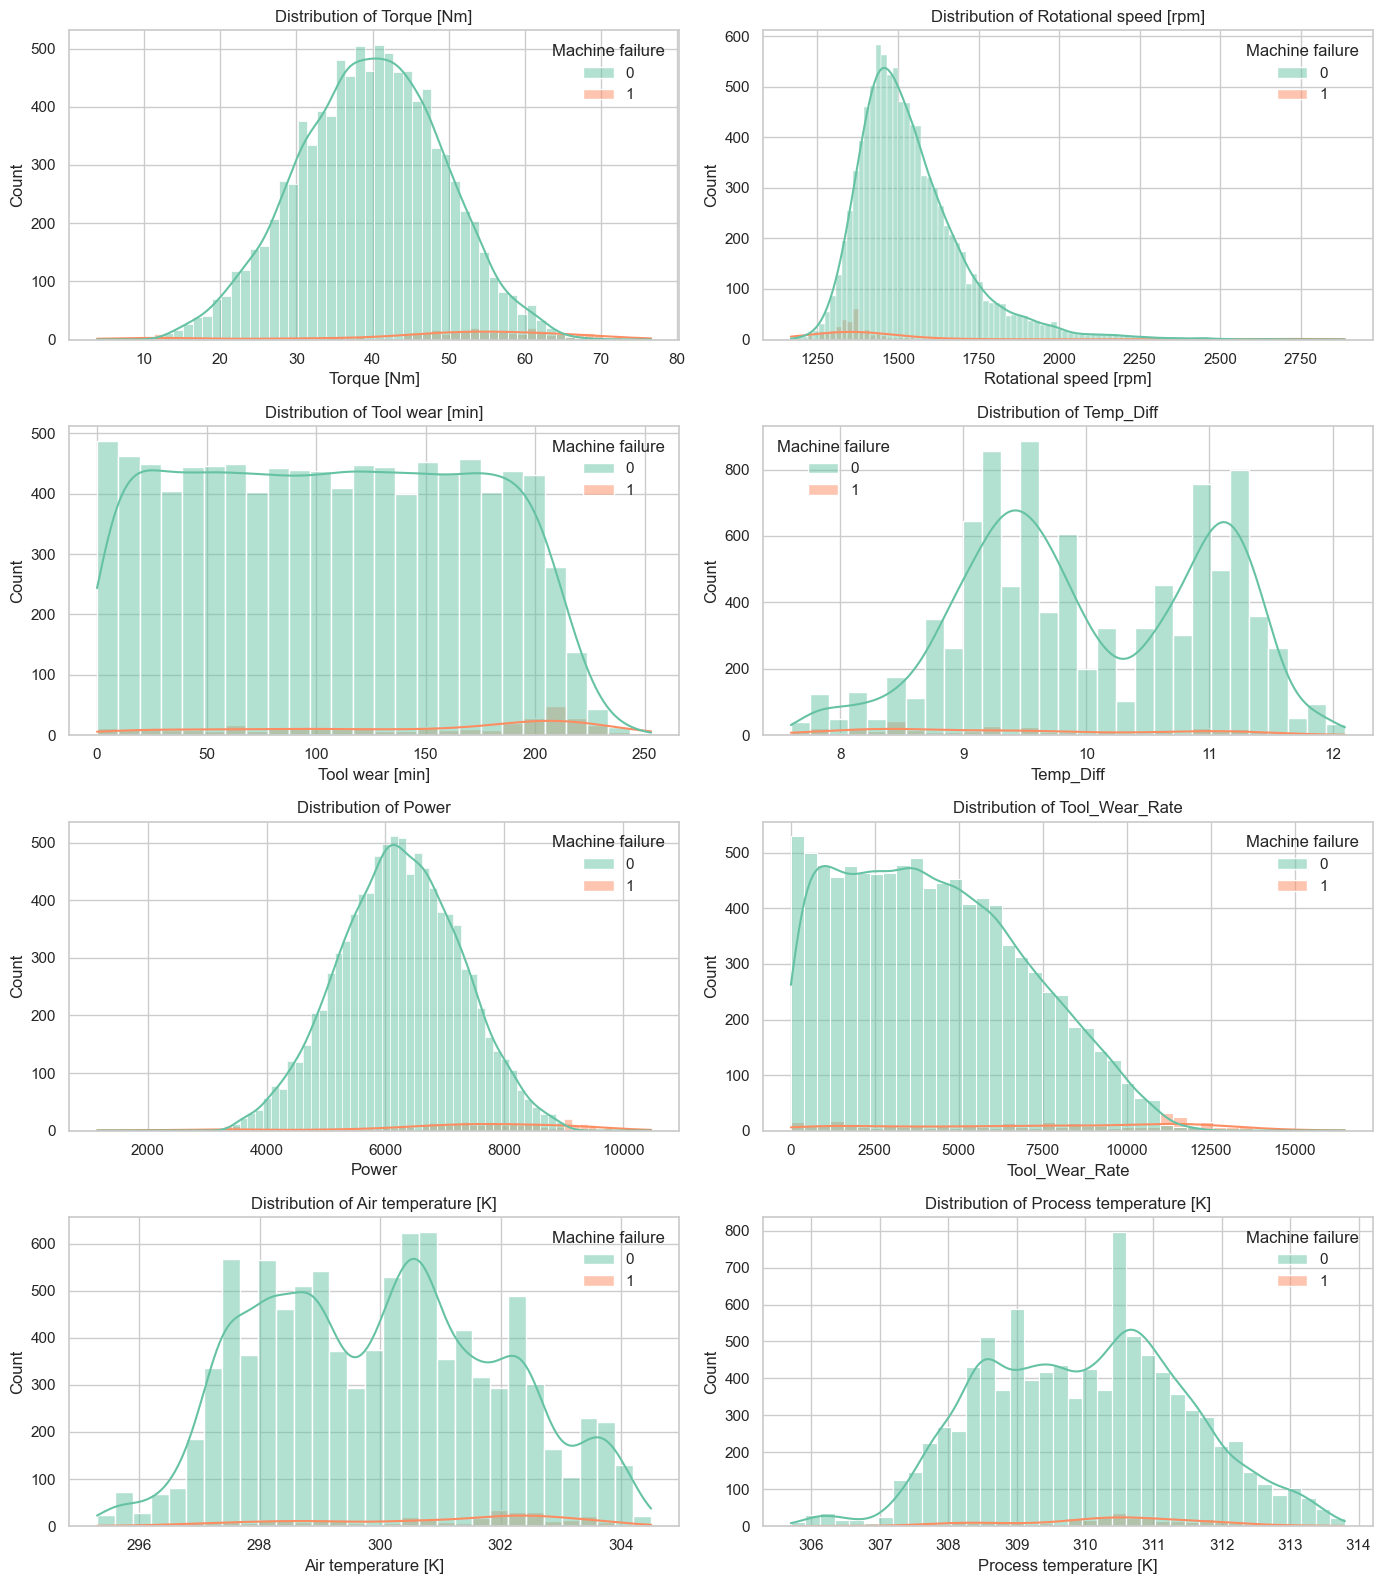

In [7]:
top_features = ["Torque [Nm]", "Rotational speed [rpm]", "Tool wear [min]", 
               "Temp_Diff", "Power", "Tool_Wear_Rate", "Air temperature [K]", "Process temperature [K]"]
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
for i, col in enumerate(top_features):
    r, c = i // 2, i % 2
    if col in df.columns:
        sns.histplot(data=df, x=col, hue=target, kde=True, ax=axes[r, c], palette="Set2")
        axes[r, c].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


## 5. Class Imbalance & SMOTE

C:\Users\chiklit\AppData\Local\Temp\ipykernel_37900\2527591236.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, ax=axes[0], palette="Set1")
C:\Users\chiklit\AppData\Local\Temp\ipykernel_37900\2527591236.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_res, ax=axes[1], palette="Set1")


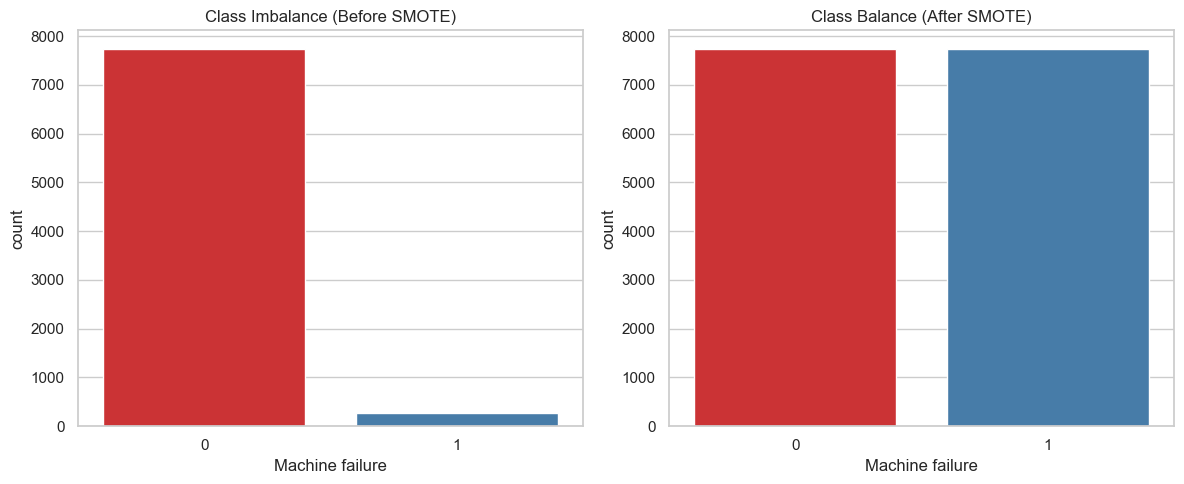

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=y_train, ax=axes[0], palette="Set1")
axes[0].set_title("Class Imbalance (Before SMOTE)")
sns.countplot(x=y_train_res, ax=axes[1], palette="Set1")
axes[1].set_title("Class Balance (After SMOTE)")
plt.tight_layout()
plt.show()


## 6. Model Training & Evaluation

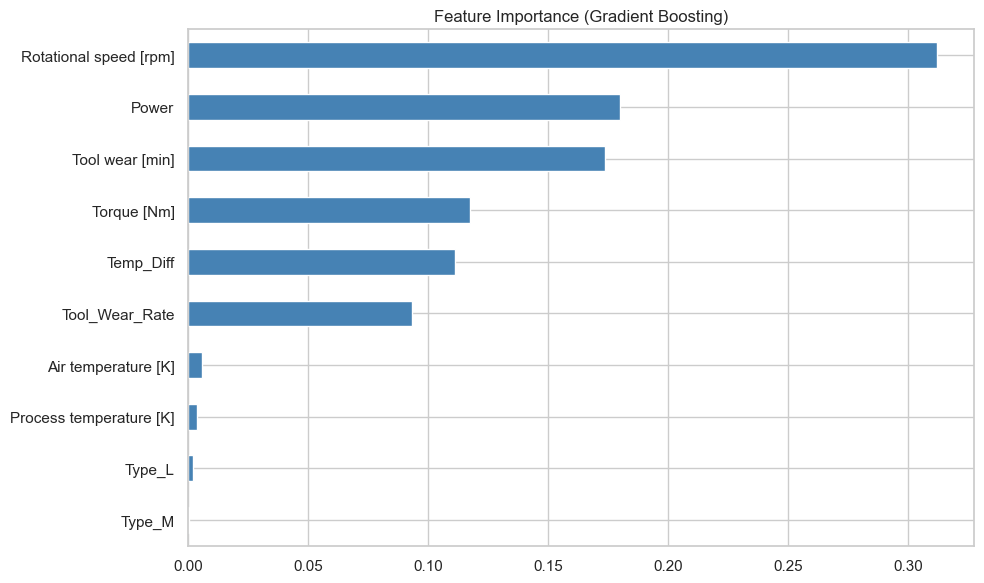

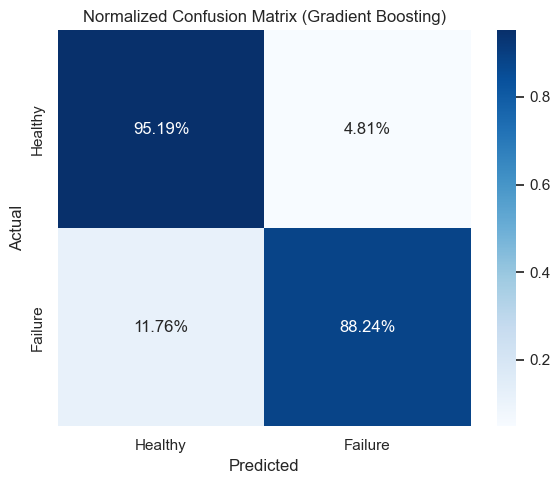

In [9]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(random_state=42)
lr = LogisticRegression(max_iter=1000, random_state=42)

rf.fit(X_train_res, y_train_res)
gb.fit(X_train_res, y_train_res)
lr.fit(X_train_res, y_train_res)

# Feature Importance
plt.figure(figsize=(10, 6))
importances = pd.Series(gb.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh', color='steelblue')
plt.title("Feature Importance (Gradient Boosting)")
plt.tight_layout()
plt.show()

# Final Model Confusion Matrix
y_pred_gb = gb.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_gb, normalize='true')
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=".2%", cmap="Blues", xticklabels=["Healthy", "Failure"], yticklabels=["Healthy", "Failure"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Normalized Confusion Matrix (Gradient Boosting)")
plt.tight_layout()
plt.show()
